## Monte Carlo Pi Calculation Serial

In [9]:
import random
import time
import math

def calculate_pi_serial(num_samples):
    inside_circle = 0

    for _ in range(num_samples):
        x = random.uniform(-1, 1)
        y = random.uniform(-1, 1)

        if x**2 + y**2 <= 1:
            inside_circle += 1

    pi_estimate = 4 * inside_circle / num_samples
    return pi_estimate

# Testing
if __name__ == "__main__":
    num_samples = 10_000_000
    num_tries = 10

    acc_time = 0
    acc_est = 0

    print("Attempt number...", end='')
    for i in range(num_tries):
        print(f" {i}:", end='')
        start_time = time.time()
        pi_est = calculate_pi_serial(num_samples)
        end_time = time.time()
        print(f" {end_time - start_time:.2f}s", end='')

        acc_time += end_time - start_time
        acc_est += pi_est

    avg_time = acc_time / num_tries
    avg_est = acc_est / num_tries

    print()
    print()
    print(f"Number of runs: {num_tries}")
    print(f"Number of samples: {num_samples}")
    print(f"Estimated value of pi: {avg_est}")
    print(f"Real value of pi: {math.pi}")
    print(f"Error: {abs(avg_est - math.pi):.10f}")
    print(f"Time: {avg_time:.4f} seconds")

Attempt number... 0: 9.31s 1: 8.76s 2: 8.63s 3: 9.48s 4: 10.60s 5: 8.52s 6: 8.66s 7: 8.71s 8: 8.54s 9: 8.57s

Number of runs: 10
Number of samples: 10000000
Estimated value of pi: 3.1414876400000002
Real value of pi: 3.141592653589793
Error: 0.0001050136
Time: 8.9784 seconds


## Monte Carlo Pi Calculation Parallel

In [10]:
import multiprocessing
import random
import time
import math

def monte_carlo_chunk(chunk_size):
    """Menghitung titik dalam lingkaran untuk sejumlah sampel"""
    inside = 0
    for _ in range(chunk_size):
        x = random.uniform(-1, 1)
        y = random.uniform(-1, 1)

        if x**2 + y**2 <= 1:
            inside += 1
    return inside

def calculate_pi_parallel(num_samples, num_processes):
    """Menghitung pi menggunakan multiprocessing"""
    chunk_size = num_samples // num_processes

    # Worker pool
    with multiprocessing.Pool(processes=num_processes) as pool:
        results = pool.map(monte_carlo_chunk, [chunk_size] * num_processes)

    total_inside = sum(results)
    pi_estimate = 4 * total_inside / (chunk_size * num_processes)
    return pi_estimate

# Testing
if __name__ == "__main__":
    num_samples = 10000000
    num_tries = 10

    print(f"Real value of pi: {math.pi}")
    print()
    
    for num_procs in [1, 2, 4, 8, 16, 32]:
        acc_time = 0
        acc_est = 0
    
        print("Attempt number...", end='')
        for i in range(num_tries):
            print(f" {i}:", end='')
            start_time = time.time()
            pi_est = calculate_pi_parallel(num_samples, num_procs)
            end_time = time.time()
            print(f" {end_time - start_time:.2f}s", end='')
            
            acc_time += end_time - start_time
            acc_est += pi_est
    
        avg_time = acc_time / num_tries
        avg_est = acc_est / num_tries

        print()
        print()
        print(f"Number of Processes: {num_procs}")
        print(f"Number of runs: {num_tries}")
        print(f"Number of samples: {num_samples}")
        print(f"Estimated value of Pi: {avg_est}")
        print(f"Error: {abs(avg_est - math.pi):.10f}")
        print(f"Time: {avg_time:.4f} seconds")
        print()

Real value of pi: 3.141592653589793

Attempt number... 0: 8.95s 1: 8.57s 2: 8.72s 3: 8.59s 4: 9.05s 5: 8.66s 6: 8.81s 7: 8.57s 8: 8.56s 9: 8.79s

Number of Processes: 1
Number of runs: 10
Number of samples: 10000000
Estimated value of Pi: 3.1414033199999998
Error: 0.0001893336
Time: 8.7273 seconds

Attempt number... 0: 5.31s 1: 5.44s 2: 5.82s 3: 5.08s 4: 5.25s 5: 5.10s 6: 5.24s 7: 4.95s 8: 5.34s 9: 4.91s

Number of Processes: 2
Number of runs: 10
Number of samples: 10000000
Estimated value of Pi: 3.1414855999999998
Error: 0.0001070536
Time: 5.2442 seconds

Attempt number... 0: 5.08s 1: 4.92s 2: 5.09s 3: 5.33s 4: 5.29s 5: 5.52s 6: 5.24s 7: 5.31s 8: 5.61s 9: 5.16s

Number of Processes: 4
Number of runs: 10
Number of samples: 10000000
Estimated value of Pi: 3.1419274799999997
Error: 0.0003348264
Time: 5.2548 seconds

Attempt number... 0: 5.33s 1: 5.30s 2: 5.52s 3: 5.90s 4: 5.22s 5: 5.23s 6: 5.15s 7: 5.56s 8: 5.50s 9: 5.32s

Number of Processes: 8
Number of runs: 10
Number of samples: 1000

## Monte Carlo Pi Calculation Serial for Different Sample Counts

In [53]:
import random
import time
import math

def calculate_pi_serial(num_samples):
    inside_circle = 0

    for _ in range(num_samples):
        x = random.uniform(-1, 1)
        y = random.uniform(-1, 1)

        if x**2 + y**2 <= 1:
            inside_circle += 1

    pi_estimate = 4 * inside_circle / num_samples
    return pi_estimate

# Testing
if __name__ == "__main__":
    num_tries = 10
    
    print(f"Real value of pi: {math.pi}")
    print()

    for num_samples in [100, 1_000, 10_000, 100_000, 1_000_000, 10_000_000]:
        print(f"Number of samples: {num_samples}")
        print(f"Number of runs: {num_tries}")
        
        acc_time = 0
        acc_est = 0
    
        print("Attempt number...", end='')
        for i in range(num_tries):
            print(f" {i}:", end='')
            start_time = time.time()
            pi_est = calculate_pi_serial(num_samples)
            end_time = time.time()
            print(f" {end_time - start_time:.2f}s", end='')
    
            acc_time += end_time - start_time
            acc_est += pi_est
    
        avg_time = acc_time / num_tries
        avg_est = acc_est / num_tries

        print()
        print(f"Estimated value of pi: {avg_est}")
        print(f"Error: {abs(avg_est - math.pi):.10f}")
        print(f"Time: {avg_time:.4f} seconds")
        print()

Real value of pi: 3.141592653589793

Number of samples: 100
Number of runs: 10
Attempt number... 0: 0.00s 1: 0.00s 2: 0.00s 3: 0.00s 4: 0.00s 5: 0.00s 6: 0.00s 7: 0.00s 8: 0.00s 9: 0.00s
Estimated value of pi: 3.0759999999999996
Error: 0.0655926536
Time: 0.0001 seconds

Number of samples: 1000
Number of runs: 10
Attempt number... 0: 0.00s 1: 0.00s 2: 0.00s 3: 0.00s 4: 0.00s 5: 0.00s 6: 0.00s 7: 0.00s 8: 0.00s 9: 0.00s
Estimated value of pi: 3.1624
Error: 0.0208073464
Time: 0.0011 seconds

Number of samples: 10000
Number of runs: 10
Attempt number... 0: 0.01s 1: 0.01s 2: 0.01s 3: 0.02s 4: 0.01s 5: 0.01s 6: 0.01s 7: 0.01s 8: 0.01s 9: 0.01s
Estimated value of pi: 3.1372399999999994
Error: 0.0043526536
Time: 0.0114 seconds

Number of samples: 100000
Number of runs: 10
Attempt number... 0: 0.09s 1: 0.09s 2: 0.09s 3: 0.09s 4: 0.10s 5: 0.10s 6: 0.09s 7: 0.10s 8: 0.09s 9: 0.10s
Estimated value of pi: 3.1413640000000003
Error: 0.0002286536
Time: 0.0946 seconds

Number of samples: 1000000
Number

## Output Data
Current CPU: Intel(R) Core(TM) i7-3520M (4) @ 2.90 GHz

In [56]:
process_counts = [1, 2, 4, 8, 16, 32]
parallel_exec_times = [8.7273, 5.2442, 5.2548, 5.4014, 5.5432, 6.4901]
# serial_exec_time = 8.9784
serial_exec_time = parallel_exec_times[0]

speedups = [0] * len(process_counts)
efficiencies = [0] * len(process_counts)

sample_counts = [100, 1_000, 10_000, 100_000, 1_000_000, 10_000_000]
serial_exec_times_over_samples = [0.0001, 0.0011, 0.0114, 0.0946, 0.8702, 8.6774]

if __name__ == "__main__":
    for i in range(len(process_counts)):
        speedups[i] = serial_exec_time / parallel_exec_times[i]
        efficiencies[i] = speedups[i] / process_counts[i]

        print(f"Process Count: {process_counts[i]}")
        print(f"Speedup: {speedups[i]}")
        print(f"Efficiency: {efficiencies[i]}")
        print()

Process Count: 1
Speedup: 1.0
Efficiency: 1.0

Process Count: 2
Speedup: 1.6641813813355706
Efficiency: 0.8320906906677853

Process Count: 4
Speedup: 1.6608243891299381
Efficiency: 0.41520609728248453

Process Count: 8
Speedup: 1.6157477690969009
Efficiency: 0.2019684711371126

Process Count: 16
Speedup: 1.5744155000721605
Efficiency: 0.09840096875451003

Process Count: 32
Speedup: 1.3447096346743501
Efficiency: 0.04202217608357344



## Visualization

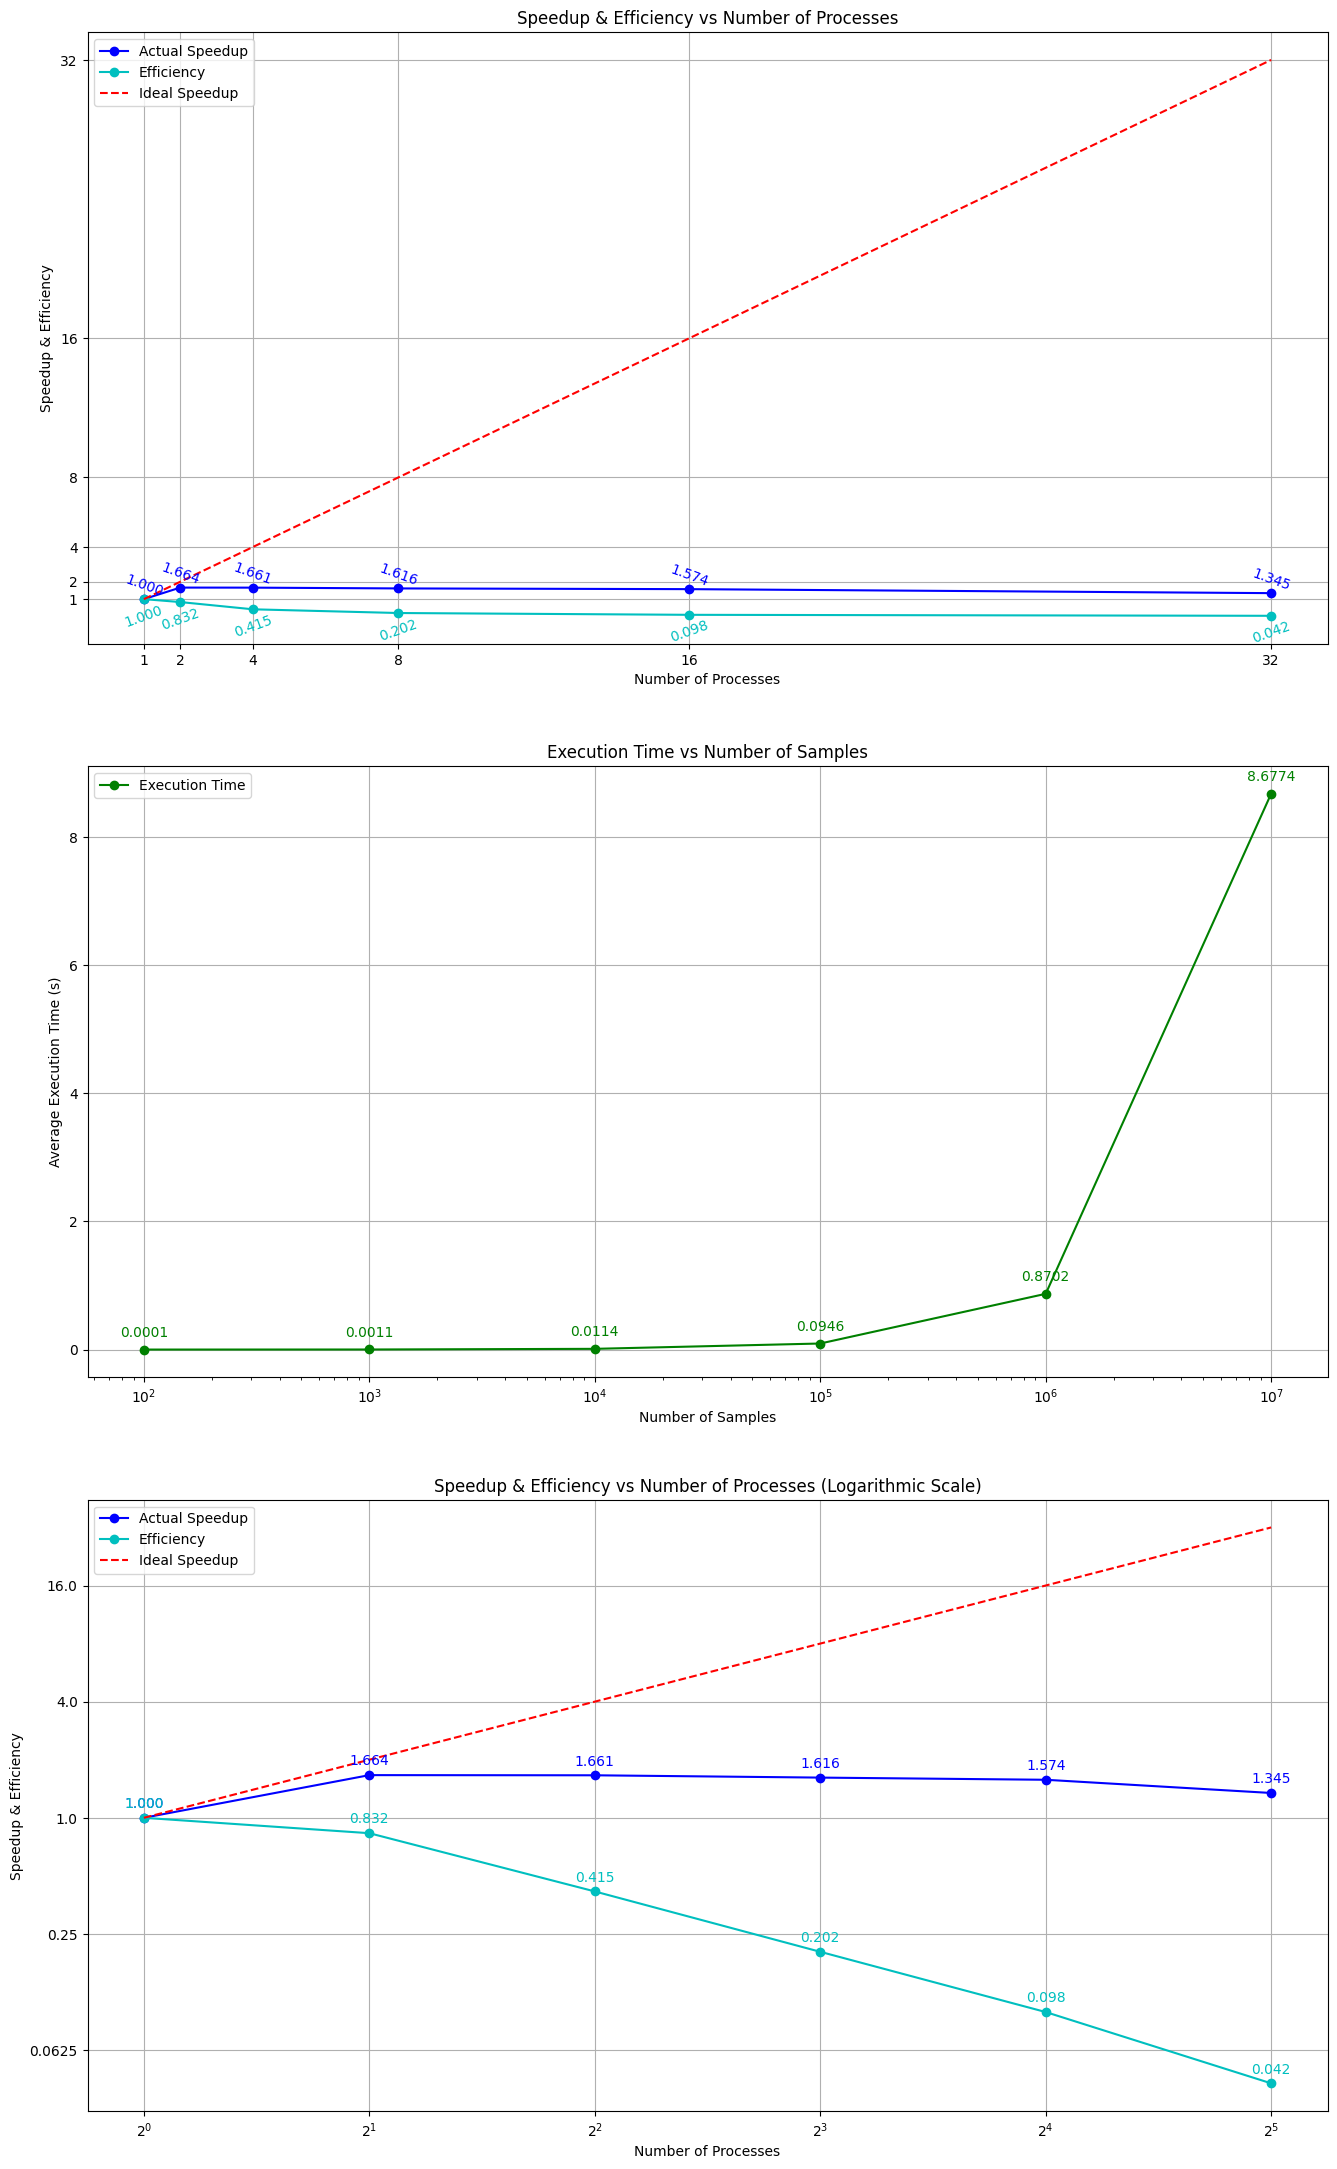

In [104]:
import matplotlib.pyplot as plt
import math

fig = plt.figure(figsize=(16, 9 * 3))

ax = plt.subplot(3, 1, 1)
ax.set_title('Speedup & Efficiency vs Number of Processes')
ax.plot(process_counts, speedups, 'bo-', label='Actual Speedup')
ax.plot(process_counts, efficiencies, 'co-', label='Efficiency')
ax.plot(process_counts, process_counts, 'r--', label='Ideal Speedup')
ax.set_xticks(process_counts)
ax.set_yticks(process_counts)
ax.set_xlabel('Number of Processes')
ax.set_ylabel('Speedup & Efficiency')
for i in range(len(process_counts)):
    ax.annotate(f'{speedups[i]:.3f}', xy=(process_counts[i], speedups[i] + .2), ha='center', rotation=-20, c='b')
    ax.annotate(f'{efficiencies[i]:.3f}', xy=(process_counts[i], efficiencies[i] - .2), ha='center', va='top', rotation=20, c='c')
ax.legend()
ax.grid(True)

ax2 = plt.subplot(3, 1, 2)
ax2.set_title('Execution Time vs Number of Samples')
ax2.plot(sample_counts, serial_exec_times_over_samples, 'go-', label='Execution Time')
ax2.set_xticks(sample_counts)
ax2.set_xlabel('Number of Samples')
ax2.set_ylabel('Average Execution Time (s)')
ax2.set_xscale('log')
for i in range(len(sample_counts)):
    exec_time = serial_exec_times_over_samples[i]
    ax2.annotate(f'{exec_time}', xy=(sample_counts[i], exec_time + .2), ha='center', c='g')
ax2.legend()
ax2.grid(True)

ax3 = plt.subplot(3, 1, 3)
ax3.set_title('Speedup & Efficiency vs Number of Processes (Logarithmic Scale)')
ax3.plot(process_counts, speedups, 'bo-', label='Actual Speedup')
ax3.plot(process_counts, efficiencies, 'co-', label='Efficiency')
ax3.plot(process_counts, process_counts, 'r--', label='Ideal Speedup')
ax3.set_xticks(process_counts)
ax3.set_xscale('log', base=2)
ax3.set_yscale('log', base=2)
ax3.yaxis.set_major_formatter('{x}')
ax3.set_xlabel('Number of Processes')
ax3.set_ylabel('Speedup & Efficiency')
for i in range(len(process_counts)):
    ax3.annotate(f'{speedups[i]:.3f}', xy=(process_counts[i], speedups[i]), xytext=(0, 10), textcoords='offset pixels', ha='center', c='b')
    ax3.annotate(f'{efficiencies[i]:.3f}', xy=(process_counts[i], efficiencies[i]), xytext=(0, 10), textcoords='offset pixels',ha='center', c='c')
ax3.legend()
ax3.grid(True)

extent1 = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted()).expanded(1.1, 1.2)
plt.savefig('speedup_analysis_1.png', bbox_inches=extent1)

extent2 = ax2.get_window_extent().transformed(fig.dpi_scale_trans.inverted()).expanded(1.1, 1.2)
plt.savefig('speedup_analysis_2.png', bbox_inches=extent2)

extent3 = ax3.get_window_extent().transformed(fig.dpi_scale_trans.inverted()).expanded(1.1, 1.2)
plt.savefig('speedup_analysis_3.png', bbox_inches=extent3)

plt.savefig('speedup_analysis.png')
plt.show()